In [43]:
import os
import numpy as np
import pandas as pd
from PIL import Image

In [44]:
dataset_path = "."
spiral_path = os.path.join(dataset_path, "spiral")

print(spiral_path)

.\spiral


In [45]:
healthy_path = "./spiral/training/healthy"

image_name = os.listdir(healthy_path)[0]
image_path = os.path.join(healthy_path, image_name)

image = Image.open(image_path)

print("Image name:", image_name)
print("Image size:", image.size)
print("Image mode:", image.mode)

Image name: aug_0_V01HE02.png
Image size: (256, 256)
Image mode: RGB


In [46]:
image_array = np.array(image)

print("Shape:", image_array.shape)
print("Data type:", image_array.dtype)
print("Minimum pixel value:", image_array.min())
print("Maximum pixel value:", image_array.max())

Shape: (256, 256, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [47]:
gray_image = image.convert("L")
gray_array = np.array(gray_image)

dark_pixels = np.sum(gray_array < 128)
total_pixels = gray_array.size

ink_ratio = dark_pixels / total_pixels

print("Dark pixels:", dark_pixels)
print("Total pixels:", total_pixels)
print("Ink ratio:", ink_ratio)

Dark pixels: 9389
Total pixels: 65536
Ink ratio: 0.1432647705078125


In [48]:
average_intensity = np.mean(gray_array)

print("Average pixel intensity:", average_intensity)

Average pixel intensity: 200.1985321044922


In [49]:
pixel_std = np.std(gray_array)

print("Pixel intensity standard deviation:", pixel_std)

Pixel intensity standard deviation: 77.71910731609262


In [50]:
def extract_features(image_path):
    image = Image.open(image_path).convert("L")
    gray_array = np.array(image)

    # Feature 1: Ink ratio
    dark_pixels = np.sum(gray_array < 128)
    total_pixels = gray_array.size
    ink_ratio = dark_pixels / total_pixels

    # Feature 2: Average pixel intensity
    average_intensity = np.mean(gray_array)

    # Feature 3: Pixel intensity standard deviation
    pixel_std = np.std(gray_array)

    # Feature 4: Minimum intensity
    min_intensity = np.min(gray_array)

    # Feature 5: Maximum intensity
    max_intensity = np.max(gray_array)

    # Feature 6: Image width
    height, width = gray_array.shape

    return {
        "Ink_Ratio": ink_ratio,
        "Average_Intensity": average_intensity,
        "Pixel_STD": pixel_std,
        "Min_Intensity": min_intensity,
        "Max_Intensity": max_intensity,
        "Width": width,
        "Height": height
    }

In [51]:
features = extract_features(image_path)

print(features)

{'Ink_Ratio': np.float64(0.1432647705078125), 'Average_Intensity': np.float64(200.1985321044922), 'Pixel_STD': np.float64(77.71910731609262), 'Min_Intensity': np.uint8(0), 'Max_Intensity': np.uint8(255), 'Width': 256, 'Height': 256}


In [52]:
def process_folder(folder_path, label):
    data = []

    for file_name in os.listdir(folder_path):

        if file_name.lower().endswith((".png", ".jpg", ".jpeg")):

            image_path = os.path.join(folder_path, file_name)

            features = extract_features(image_path)

            features["Label"] = label

            data.append(features)

    return data

In [53]:
healthy_data = process_folder(
    "./spiral/training/healthy",
    0
)

print("Healthy images processed:", len(healthy_data))

Healthy images processed: 144


In [54]:
def process_folder(folder_path, label):
    data = []

    for file_name in os.listdir(folder_path):

        if file_name.lower().endswith((".png", ".jpg", ".jpeg")):

            image_path = os.path.join(folder_path, file_name)

            features = extract_features(image_path)

            features["Label"] = label

            data.append(features)

    return data

In [55]:
parkinson_data = process_folder(
    "./spiral/training/parkinson",
    1
)

print("Parkinson images processed:", len(parkinson_data))

Parkinson images processed: 144


In [56]:
all_data = healthy_data + parkinson_data

df = pd.DataFrame(all_data)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (288, 8)
   Ink_Ratio  Average_Intensity  Pixel_STD  Min_Intensity  Max_Intensity  \
0   0.143265         200.198532  77.719107              0            255   
1   0.190720         161.612549  75.345633              0            255   
2   0.145950         182.208649  71.949540              0            255   
3   0.141769         191.270721  74.943198              0            255   
4   0.078964         191.536865  45.388540              0            255   

   Width  Height  Label  
0    256     256      0  
1    256     256      0  
2    256     256      0  
3    256     256      0  
4    256     256      0  


In [57]:
print(df["Label"].value_counts())

Label
0    144
1    144
Name: count, dtype: int64


In [58]:
df.to_csv("handwriting_features.csv", index=False)

print("Feature dataset saved successfully!")

Feature dataset saved successfully!


In [59]:
df = df.drop(columns=["Width", "Height"])

print(df.shape)
print(df.head())

(288, 6)
   Ink_Ratio  Average_Intensity  Pixel_STD  Min_Intensity  Max_Intensity  \
0   0.143265         200.198532  77.719107              0            255   
1   0.190720         161.612549  75.345633              0            255   
2   0.145950         182.208649  71.949540              0            255   
3   0.141769         191.270721  74.943198              0            255   
4   0.078964         191.536865  45.388540              0            255   

   Label  
0      0  
1      0  
2      0  
3      0  
4      0  


In [60]:
df.to_csv("handwriting_features.csv", index=False)

print("Clean feature dataset saved!")

Clean feature dataset saved!


In [61]:
import pandas as pd

df = pd.read_csv("handwriting_features.csv")

print("Dataset shape:", df.shape)
print(df.head())
print(df.columns)

Dataset shape: (288, 6)
   Ink_Ratio  Average_Intensity  Pixel_STD  Min_Intensity  Max_Intensity  \
0   0.143265         200.198532  77.719107              0            255   
1   0.190720         161.612549  75.345633              0            255   
2   0.145950         182.208649  71.949540              0            255   
3   0.141769         191.270721  74.943198              0            255   
4   0.078964         191.536865  45.388540              0            255   

   Label  
0      0  
1      0  
2      0  
3      0  
4      0  
Index(['Ink_Ratio', 'Average_Intensity', 'Pixel_STD', 'Min_Intensity',
       'Max_Intensity', 'Label'],
      dtype='str')


In [62]:
print(df["Label"].value_counts())

Label
0    144
1    144
Name: count, dtype: int64


In [63]:
X = df.drop("Label", axis=1)
y = df["Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (288, 5)
y shape: (288,)


In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (230, 5)
Testing: (58, 5)


In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.5344827586206896
              precision    recall  f1-score   support

           0       0.53      0.62      0.57        29
           1       0.54      0.45      0.49        29

    accuracy                           0.53        58
   macro avg       0.54      0.53      0.53        58
weighted avg       0.54      0.53      0.53        58



[[18 11]
 [16 13]]


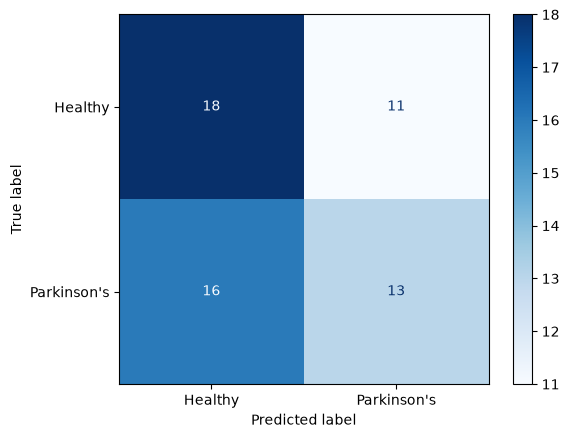

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy", "Parkinson's"]
)

disp.plot(cmap="Blues")
plt.show()

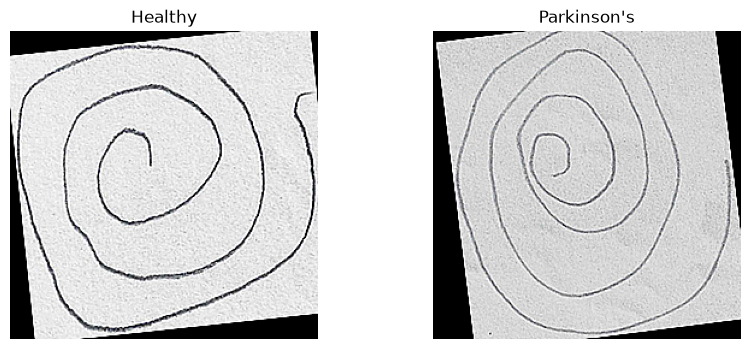

In [67]:
import matplotlib.pyplot as plt
from PIL import Image
import os

healthy_path = "./spiral/training/healthy"
parkinson_path = "./spiral/training/parkinson"

healthy_image = os.listdir(healthy_path)[0]
parkinson_image = os.listdir(parkinson_path)[0]

healthy_img = Image.open(
    os.path.join(healthy_path, healthy_image)
)

parkinson_img = Image.open(
    os.path.join(parkinson_path, parkinson_image)
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(healthy_img)
plt.title("Healthy")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(parkinson_img)
plt.title("Parkinson's")
plt.axis("off")

plt.show()

In [68]:
import os

folders = [
    "./spiral/training/healthy",
    "./spiral/training/parkinson",
    "./spiral/validation/healthy",
    "./spiral/validation/parkinson",
    "./spiral/testing/healthy",
    "./spiral/testing/parkinson",
    "./wave/training/healthy",
    "./wave/training/parkinson",
    "./wave/validation/healthy",
    "./wave/validation/parkinson",
    "./wave/testing/healthy",
    "./wave/testing/parkinson"
]

for folder in folders:
    if os.path.exists(folder):
        count = len([
            f for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ])
        print(f"{folder}: {count}")
    else:
        print(f"{folder}: NOT FOUND")

./spiral/training/healthy: 144
./spiral/training/parkinson: 144
./spiral/validation/healthy: 36
./spiral/validation/parkinson: 36
./spiral/testing/healthy: 75
./spiral/testing/parkinson: 75
./wave/training/healthy: 144
./wave/training/parkinson: 144
./wave/validation/healthy: 36
./wave/validation/parkinson: 36
./wave/testing/healthy: 75
./wave/testing/parkinson: 75


In [69]:
from skimage.feature import hog
from PIL import Image
import numpy as np
import os
import pandas as pd

def extract_hog_features(image_path):
    image = Image.open(image_path).convert("L")

    # Resize every image to the same size
    image = image.resize((256, 256))

    image = np.array(image)

    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    return features




def process_hog_folder(folder_path, label):
    data = []

    for file_name in os.listdir(folder_path):

        if file_name.lower().endswith((".png", ".jpg", ".jpeg")):

            image_path = os.path.join(folder_path, file_name)

            hog_features = extract_hog_features(image_path)

            row = list(hog_features)
            row.append(label)

            data.append(row)

    return data


# Training
spiral_train_healthy = process_hog_folder(
    "./spiral/training/healthy", 0
)

spiral_train_parkinson = process_hog_folder(
    "./spiral/training/parkinson", 1
)


# Validation
spiral_val_healthy = process_hog_folder(
    "./spiral/validation/healthy", 0
)

spiral_val_parkinson = process_hog_folder(
    "./spiral/validation/parkinson", 1
)


# Testing
spiral_test_healthy = process_hog_folder(
    "./spiral/testing/healthy", 0
)

spiral_test_parkinson = process_hog_folder(
    "./spiral/testing/parkinson", 1
)


# Combine datasets
train_data = spiral_train_healthy + spiral_train_parkinson
val_data = spiral_val_healthy + spiral_val_parkinson
test_data = spiral_test_healthy + spiral_test_parkinson


# Create DataFrames
train_df = pd.DataFrame(train_data)
val_df = pd.DataFrame(val_data)
test_df = pd.DataFrame(test_data)


print("Training shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Testing shape:", test_df.shape)

print("\nTraining labels:")
print(train_df.iloc[:, -1].value_counts())

print("\nValidation labels:")
print(val_df.iloc[:, -1].value_counts())

print("\nTesting labels:")
print(test_df.iloc[:, -1].value_counts())

Training shape: (288, 8101)
Validation shape: (72, 8101)
Testing shape: (150, 8101)

Training labels:
8100
0    144
1    144
Name: count, dtype: int64

Validation labels:
8100
0    36
1    36
Name: count, dtype: int64

Testing labels:
8100
0    75
1    75
Name: count, dtype: int64


In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Separate features and labels
X_train = train_df.iloc[:, :-1]
y_train = train_df.iloc[:, -1]

X_val = val_df.iloc[:, :-1]
y_val = val_df.iloc[:, -1]

X_test = test_df.iloc[:, :-1]
y_test = test_df.iloc[:, -1]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

# Random Forest
rf_hog = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
rf_hog.fit(X_train, y_train)

# Validation prediction
y_val_pred = rf_hog.predict(X_val)

# Validation accuracy
val_accuracy = accuracy_score(y_val, y_val_pred)

print("\nValidation Accuracy:", val_accuracy)

# Final testing
y_test_pred = rf_hog.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)

print("Testing Accuracy:", test_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Healthy", "Parkinson's"]
    )
)

X_train: (288, 8100)
X_val: (72, 8100)
X_test: (150, 8100)

Validation Accuracy: 0.7777777777777778
Testing Accuracy: 0.6666666666666666

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.65      0.73      0.69        75
 Parkinson's       0.69      0.60      0.64        75

    accuracy                           0.67       150
   macro avg       0.67      0.67      0.67       150
weighted avg       0.67      0.67      0.67       150



In [71]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Create SVM model
svm_hog = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

# Train
svm_hog.fit(X_train, y_train)

# Validation
y_val_pred_svm = svm_hog.predict(X_val)
val_accuracy_svm = accuracy_score(y_val, y_val_pred_svm)

# Testing
y_test_pred_svm = svm_hog.predict(X_test)
test_accuracy_svm = accuracy_score(y_test, y_test_pred_svm)

print("SVM Validation Accuracy:", val_accuracy_svm)
print("SVM Testing Accuracy:", test_accuracy_svm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_svm,
        target_names=["Healthy", "Parkinson's"]
    )
)

SVM Validation Accuracy: 0.75
SVM Testing Accuracy: 0.6266666666666667

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.61      0.71      0.65        75
 Parkinson's       0.65      0.55      0.59        75

    accuracy                           0.63       150
   macro avg       0.63      0.63      0.62       150
weighted avg       0.63      0.63      0.62       150



In [72]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_hog = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt_hog.fit(X_train, y_train)

# Validation
y_val_pred_dt = dt_hog.predict(X_val)
val_accuracy_dt = accuracy_score(y_val, y_val_pred_dt)

# Testing
y_test_pred_dt = dt_hog.predict(X_test)
test_accuracy_dt = accuracy_score(y_test, y_test_pred_dt)

print("Decision Tree Validation Accuracy:", val_accuracy_dt)
print("Decision Tree Testing Accuracy:", test_accuracy_dt)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_dt,
        target_names=["Healthy", "Parkinson's"]
    )
)

Decision Tree Validation Accuracy: 0.5416666666666666
Decision Tree Testing Accuracy: 0.5466666666666666

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.55      0.49      0.52        75
 Parkinson's       0.54      0.60      0.57        75

    accuracy                           0.55       150
   macro avg       0.55      0.55      0.55       150
weighted avg       0.55      0.55      0.55       150



In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_hog = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr_hog.fit(X_train, y_train)

# Validation
y_val_pred_lr = lr_hog.predict(X_val)
val_accuracy_lr = accuracy_score(y_val, y_val_pred_lr)

# Testing
y_test_pred_lr = lr_hog.predict(X_test)
test_accuracy_lr = accuracy_score(y_test, y_test_pred_lr)

print("Logistic Regression Validation Accuracy:", val_accuracy_lr)
print("Logistic Regression Testing Accuracy:", test_accuracy_lr)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_lr,
        target_names=["Healthy", "Parkinson's"]
    )
)

Logistic Regression Validation Accuracy: 0.7361111111111112
Logistic Regression Testing Accuracy: 0.6333333333333333

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.61      0.72      0.66        75
 Parkinson's       0.66      0.55      0.60        75

    accuracy                           0.63       150
   macro avg       0.64      0.63      0.63       150
weighted avg       0.64      0.63      0.63       150



In [74]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn_hog = KNeighborsClassifier(
    n_neighbors=5
)

knn_hog.fit(X_train, y_train)

# Validation
y_val_pred_knn = knn_hog.predict(X_val)
val_accuracy_knn = accuracy_score(y_val, y_val_pred_knn)

# Testing
y_test_pred_knn = knn_hog.predict(X_test)
test_accuracy_knn = accuracy_score(y_test, y_test_pred_knn)

print("KNN Validation Accuracy:", val_accuracy_knn)
print("KNN Testing Accuracy:", test_accuracy_knn)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_knn,
        target_names=["Healthy", "Parkinson's"]
    )
)

KNN Validation Accuracy: 0.7361111111111112
KNN Testing Accuracy: 0.6133333333333333

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.61      0.63      0.62        75
 Parkinson's       0.62      0.60      0.61        75

    accuracy                           0.61       150
   macro avg       0.61      0.61      0.61       150
weighted avg       0.61      0.61      0.61       150



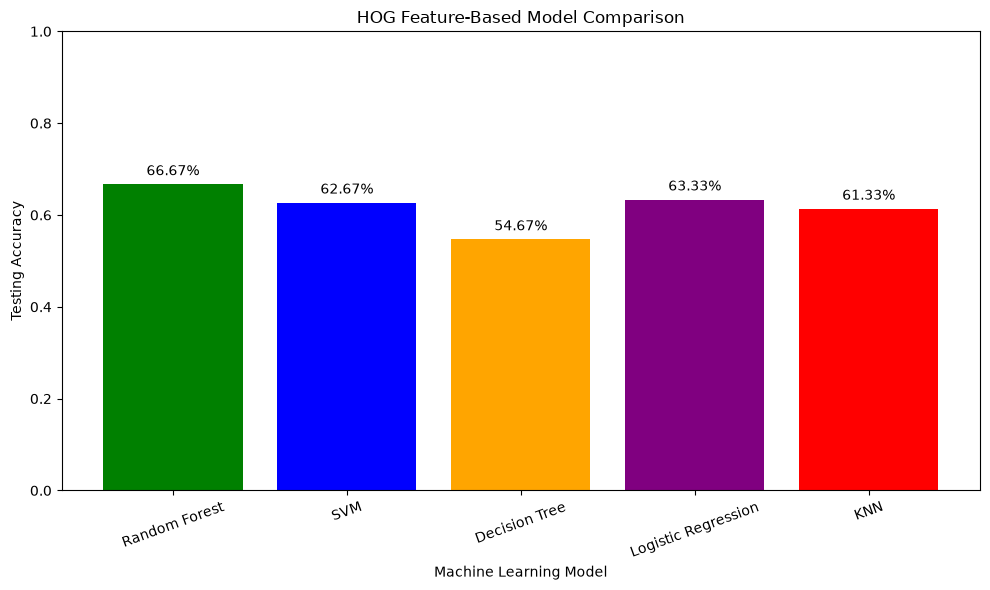

In [75]:
import matplotlib.pyplot as plt

models = [
    "Random Forest",
    "SVM",
    "Decision Tree",
    "Logistic Regression",
    "KNN"
]

test_accuracies = [
    test_accuracy,
    test_accuracy_svm,
    test_accuracy_dt,
    test_accuracy_lr,
    test_accuracy_knn
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    models,
    test_accuracies,
    color=["green", "blue", "orange", "purple", "red"]
)

plt.ylabel("Testing Accuracy")
plt.xlabel("Machine Learning Model")
plt.title("HOG Feature-Based Model Comparison")

plt.ylim(0, 1)

# Show percentage above each bar
for bar, accuracy in zip(bars, test_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{accuracy * 100:.2f}%",
        ha="center"
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [76]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale the HOG features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# PCA
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X_train.shape[1])
print("PCA features:", X_train_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_.sum())

Original features: 8100
PCA features: 220
Explained variance: 0.950287053920434


In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_pca = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train
rf_pca.fit(X_train_pca, y_train)

# Validation
y_val_pred_pca = rf_pca.predict(X_val_pca)
val_accuracy_pca = accuracy_score(y_val, y_val_pred_pca)

# Testing
y_test_pred_pca = rf_pca.predict(X_test_pca)
test_accuracy_pca = accuracy_score(y_test, y_test_pred_pca)

print("Random Forest + PCA")
print("Validation Accuracy:", val_accuracy_pca)
print("Testing Accuracy:", test_accuracy_pca)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_pca,
        target_names=["Healthy", "Parkinson's"]
    )
)

Random Forest + PCA
Validation Accuracy: 0.5694444444444444
Testing Accuracy: 0.58

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.55      0.93      0.69        75
 Parkinson's       0.77      0.23      0.35        75

    accuracy                           0.58       150
   macro avg       0.66      0.58      0.52       150
weighted avg       0.66      0.58      0.52       150



In [78]:
# WAVE HOG FEATURES

wave_train_healthy = process_hog_folder(
    "./wave/training/healthy", 0
)

wave_train_parkinson = process_hog_folder(
    "./wave/training/parkinson", 1
)

wave_val_healthy = process_hog_folder(
    "./wave/validation/healthy", 0
)

wave_val_parkinson = process_hog_folder(
    "./wave/validation/parkinson", 1
)

wave_test_healthy = process_hog_folder(
    "./wave/testing/healthy", 0
)

wave_test_parkinson = process_hog_folder(
    "./wave/testing/parkinson", 1
)

# Combine

wave_train_data = wave_train_healthy + wave_train_parkinson
wave_val_data = wave_val_healthy + wave_val_parkinson
wave_test_data = wave_test_healthy + wave_test_parkinson

# DataFrames

wave_train_df = pd.DataFrame(wave_train_data)
wave_val_df = pd.DataFrame(wave_val_data)
wave_test_df = pd.DataFrame(wave_test_data)

print("Wave Training:", wave_train_df.shape)
print("Wave Validation:", wave_val_df.shape)
print("Wave Testing:", wave_test_df.shape)

Wave Training: (288, 8101)
Wave Validation: (72, 8101)
Wave Testing: (150, 8101)


In [79]:
# Separate Wave features and labels

X_wave_train = wave_train_df.iloc[:, :-1]
y_wave_train = wave_train_df.iloc[:, -1]

X_wave_val = wave_val_df.iloc[:, :-1]
y_wave_val = wave_val_df.iloc[:, -1]

X_wave_test = wave_test_df.iloc[:, :-1]
y_wave_test = wave_test_df.iloc[:, -1]

print("X_wave_train:", X_wave_train.shape)
print("X_wave_val:", X_wave_val.shape)
print("X_wave_test:", X_wave_test.shape)

X_wave_train: (288, 8100)
X_wave_val: (72, 8100)
X_wave_test: (150, 8100)


In [80]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_wave = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_wave.fit(X_wave_train, y_wave_train)

# Validation
wave_val_pred = rf_wave.predict(X_wave_val)
wave_val_accuracy = accuracy_score(y_wave_val, wave_val_pred)

# Testing
wave_test_pred = rf_wave.predict(X_wave_test)
wave_test_accuracy = accuracy_score(y_wave_test, wave_test_pred)

print("Wave + Random Forest")
print("Validation Accuracy:", wave_val_accuracy)
print("Testing Accuracy:", wave_test_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_wave_test,
        wave_test_pred,
        target_names=["Healthy", "Parkinson's"]
    )
)

Wave + Random Forest
Validation Accuracy: 0.6388888888888888
Testing Accuracy: 0.6266666666666667

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.63      0.61      0.62        75
 Parkinson's       0.62      0.64      0.63        75

    accuracy                           0.63       150
   macro avg       0.63      0.63      0.63       150
weighted avg       0.63      0.63      0.63       150



In [81]:
def get_common_id(filename):
    filename = filename.replace("HE", "XX")
    filename = filename.replace("HO", "XX")
    filename = filename.replace("PE", "XX")
    filename = filename.replace("PO", "XX")
    return filename

In [82]:
def create_combined_features(spiral_folder, wave_folder):

    spiral_files = os.listdir(spiral_folder)
    wave_files = os.listdir(wave_folder)

    spiral_dict = {
        get_common_id(f): f
        for f in spiral_files
        if f.lower().endswith(".png")
    }

    wave_dict = {
        get_common_id(f): f
        for f in wave_files
        if f.lower().endswith(".png")
    }

    common_ids = sorted(
        set(spiral_dict.keys()) &
        set(wave_dict.keys())
    )

    combined_features = []

    for common_id in common_ids:

        spiral_path = os.path.join(
            spiral_folder,
            spiral_dict[common_id]
        )

        wave_path = os.path.join(
            wave_folder,
            wave_dict[common_id]
        )

        spiral_features = extract_hog_features(spiral_path)
        wave_features = extract_hog_features(wave_path)

        combined = np.concatenate(
            [spiral_features, wave_features]
        )

        combined_features.append(combined)

    return np.array(combined_features)

In [83]:
X_combined_train_healthy = create_combined_features(
    "./spiral/training/healthy",
    "./wave/training/healthy"
)

X_combined_train_pd = create_combined_features(
    "./spiral/training/parkinson",
    "./wave/training/parkinson"
)

print("Healthy:", X_combined_train_healthy.shape)
print("Parkinson's:", X_combined_train_pd.shape)

Healthy: (118, 16200)
Parkinson's: (131, 16200)


In [84]:
X_combined_val_healthy = create_combined_features(
    "./spiral/validation/healthy",
    "./wave/validation/healthy"
)

X_combined_val_pd = create_combined_features(
    "./spiral/validation/parkinson",
    "./wave/validation/parkinson"
)

X_combined_test_healthy = create_combined_features(
    "./spiral/testing/healthy",
    "./wave/testing/healthy"
)

X_combined_test_pd = create_combined_features(
    "./spiral/testing/parkinson",
    "./wave/testing/parkinson"
)

print("Validation Healthy:", X_combined_val_healthy.shape)
print("Validation Parkinson's:", X_combined_val_pd.shape)

print("Testing Healthy:", X_combined_test_healthy.shape)
print("Testing Parkinson's:", X_combined_test_pd.shape)

Validation Healthy: (32, 16200)
Validation Parkinson's: (33, 16200)
Testing Healthy: (50, 16200)
Testing Parkinson's: (60, 16200)


In [85]:
X_combined_train = np.vstack([
    X_combined_train_healthy,
    X_combined_train_pd
])

y_combined_train = np.array(
    [0] * len(X_combined_train_healthy) +
    [1] * len(X_combined_train_pd)
)

X_combined_val = np.vstack([
    X_combined_val_healthy,
    X_combined_val_pd
])

y_combined_val = np.array(
    [0] * len(X_combined_val_healthy) +
    [1] * len(X_combined_val_pd)
)

X_combined_test = np.vstack([
    X_combined_test_healthy,
    X_combined_test_pd
])

y_combined_test = np.array(
    [0] * len(X_combined_test_healthy) +
    [1] * len(X_combined_test_pd)
)

print("Combined Training:", X_combined_train.shape)
print("Combined Validation:", X_combined_val.shape)
print("Combined Testing:", X_combined_test.shape)

Combined Training: (249, 16200)
Combined Validation: (65, 16200)
Combined Testing: (110, 16200)


In [86]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_combined = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
rf_combined.fit(X_combined_train, y_combined_train)

# Validation
combined_val_pred = rf_combined.predict(X_combined_val)
combined_val_accuracy = accuracy_score(
    y_combined_val,
    combined_val_pred
)

# Testing
combined_test_pred = rf_combined.predict(X_combined_test)
combined_test_accuracy = accuracy_score(
    y_combined_test,
    combined_test_pred
)

print("Spiral + Wave + HOG + Random Forest")
print("Validation Accuracy:", combined_val_accuracy)
print("Testing Accuracy:", combined_test_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_combined_test,
        combined_test_pred,
        target_names=["Healthy", "Parkinson's"]
    )
)

Spiral + Wave + HOG + Random Forest
Validation Accuracy: 0.6
Testing Accuracy: 0.6909090909090909

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.65      0.68      0.67        50
 Parkinson's       0.72      0.70      0.71        60

    accuracy                           0.69       110
   macro avg       0.69      0.69      0.69       110
weighted avg       0.69      0.69      0.69       110



In [87]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    "./spiral/training",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    "./spiral/validation",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    "./spiral/testing",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class labels:", train_generator.class_indices)

Found 288 images belonging to 2 classes.
Found 72 images belonging to 2 classes.
Found 150 images belonging to 2 classes.
Class labels: {'healthy': 0, 'parkinson': 1}


In [88]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

# Build classifier
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [89]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 403ms/step - accuracy: 0.5278 - loss: 0.7255 - val_accuracy: 0.6944 - val_loss: 0.6175
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 306ms/step - accuracy: 0.6354 - loss: 0.6265 - val_accuracy: 0.7083 - val_loss: 0.5603
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 296ms/step - accuracy: 0.7118 - loss: 0.5432 - val_accuracy: 0.7639 - val_loss: 0.5329
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 344ms/step - accuracy: 0.7569 - loss: 0.4867 - val_accuracy: 0.7500 - val_loss: 0.5023
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 353ms/step - accuracy: 0.7847 - loss: 0.4757 - val_accuracy: 0.7778 - val_loss: 0.4766
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 348ms/step - accuracy: 0.7743 - loss: 0.4723 - val_accuracy: 0.8056 - val_loss: 0.4744
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 353ms/step - accuracy: 0.8021 - loss: 0.4451 - val_accuracy: 0.8056 - val_loss: 0.4372
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 343ms/step - accuracy: 0.8160 - loss: 0.4237 - val_accuracy: 0

In [90]:
# Unfreeze the MobileNetV2 base model
base_model.trainable = True

# Freeze the first 100 layers
for layer in base_model.layers[:100]:
    layer.trainable = False

# Use a very small learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Trainable layers:",
      sum(layer.trainable for layer in model.layers))


Trainable layers: 4


In [91]:
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 599ms/step - accuracy: 0.5000 - loss: 2.4344 - val_accuracy: 0.8194 - val_loss: 0.3962
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 512ms/step - accuracy: 0.5000 - loss: 1.9274 - val_accuracy: 0.8056 - val_loss: 0.3936
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 512ms/step - accuracy: 0.5035 - loss: 1.5109 - val_accuracy: 0.8056 - val_loss: 0.3944
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 554ms/step - accuracy: 0.5417 - loss: 1.0375 - val_accuracy: 0.7917 - val_loss: 0.4024
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 564ms/step - accuracy: 0.6632 - loss: 0.6298 - val_accuracy: 0.7917 - val_loss: 0.4196
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 558ms/step - accuracy: 0.7917 - loss: 0.4610 - val_accuracy: 0.7778 - val_loss: 0.4422
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 549ms/step - accuracy: 0.8646 - loss: 0.3097 - val_accuracy: 0.7778 - val_loss: 0.4549
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 560ms/step - accuracy: 0.8611 - loss: 0.2941 - val_accura

In [92]:
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator_aug = train_datagen_aug.flow_from_directory(
    "./spiral/training",
    target_size=(224, 224),
    batch_size=16,
    class_mode="binary",
    shuffle=True,
    seed=42
)

Found 288 images belonging to 2 classes.


In [93]:
# Freeze MobileNetV2 again
base_model.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 frozen again.")

MobileNetV2 frozen again.


In [94]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_aug = model.fit(
    train_generator_aug,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 611ms/step - accuracy: 0.7396 - loss: 0.4630 - val_accuracy: 0.8056 - val_loss: 0.3957
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 470ms/step - accuracy: 0.8090 - loss: 0.4127 - val_accuracy: 0.8472 - val_loss: 0.3722
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 469ms/step - accuracy: 0.8333 - loss: 0.3590 - val_accuracy: 0.8333 - val_loss: 0.3694
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 463ms/step - accuracy: 0.8056 - loss: 0.3729 - val_accuracy: 0.7917 - val_loss: 0.3726
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 464ms/step - accuracy: 0.8681 - loss: 0.3309 - val_accuracy: 0.7917 - val_loss: 0.3725
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 467ms/step - accuracy: 0.7951 - loss: 0.3960 - val_accuracy: 0.7917 - val_loss: 0.3751


In [95]:
test_generator.reset()

test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 338ms/step - accuracy: 0.7533 - loss: 0.6316
Test Loss: 0.6316049695014954
Test Accuracy: 0.753333330154419


In [96]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Reset test generator
test_generator.reset()

# Get predictions
predictions = model.predict(test_generator)

# Convert probabilities to 0 or 1
y_pred = (predictions > 0.5).astype(int).flatten()

# Get actual labels
y_true = test_generator.classes

print("Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Healthy", "Parkinson"]
))

10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 534ms/step
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.74      0.79      0.76        75
   Parkinson       0.77      0.72      0.74        75

    accuracy                           0.75       150
   macro avg       0.75      0.75      0.75       150
weighted avg       0.75      0.75      0.75       150



In [97]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[59 16]
 [21 54]]


In [98]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    "./wave/training",
    target_size=(128, 128),
    batch_size=16,
    class_mode="binary",
    shuffle=True
)

validation_generator = test_datagen.flow_from_directory(
    "./wave/validation",
    target_size=(128, 128),
    batch_size=16,
    class_mode="binary",
    shuffle=False
)

test_generator_wave = test_datagen.flow_from_directory(
    "./wave/testing",
    target_size=(128, 128),
    batch_size=16,
    class_mode="binary",
    shuffle=False
)

Found 288 images belonging to 2 classes.
Found 72 images belonging to 2 classes.
Found 150 images belonging to 2 classes.


In [99]:
print("Training images:", train_generator.samples)
print("Validation images:", validation_generator.samples)
print("Testing images:", test_generator_wave.samples)

print("Classes:", train_generator.class_indices)

Training images: 288
Validation images: 72
Testing images: 150
Classes: {'healthy': 0, 'parkinson': 1}


In [100]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def improve_contrast(image):
    return tf.image.adjust_contrast(image, 2.5)

wave_train_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=improve_contrast
)

wave_test_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=improve_contrast
)

wave_train_generator = wave_train_datagen.flow_from_directory(
    "./wave/training",
    target_size=(128, 128),
    batch_size=16,
    class_mode="binary",
    shuffle=True
)

wave_validation_generator = wave_test_datagen.flow_from_directory(
    "./wave/validation",
    target_size=(128, 128),
    batch_size=16,
    class_mode="binary",
    shuffle=False
)

wave_test_generator = wave_test_datagen.flow_from_directory(
    "./wave/testing",
    target_size=(128, 128),
    batch_size=16,
    class_mode="binary",
    shuffle=False
)

print("Training:", wave_train_generator.samples)
print("Validation:", wave_validation_generator.samples)
print("Testing:", wave_test_generator.samples)

Found 288 images belonging to 2 classes.
Found 72 images belonging to 2 classes.
Found 150 images belonging to 2 classes.
Training: 288
Validation: 72
Testing: 150


In [101]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def improve_contrast(image):
    return tf.image.adjust_contrast(image, 2.5)

wave_train_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=improve_contrast
)

wave_test_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=improve_contrast
)

wave_train_generator = wave_train_datagen.flow_from_directory(
    "./wave/training",
    target_size=(128, 128),
    batch_size=16,
    class_mode="binary",
    shuffle=True
)

wave_validation_generator = wave_test_datagen.flow_from_directory(
    "./wave/validation",
    target_size=(128, 128),
    batch_size=16,
    class_mode="binary",
    shuffle=False
)

wave_test_generator = wave_test_datagen.flow_from_directory(
    "./wave/testing",
    target_size=(128, 128),
    batch_size=16,
    class_mode="binary",
    shuffle=False
)

print("Training:", wave_train_generator.samples)
print("Validation:", wave_validation_generator.samples)
print("Testing:", wave_test_generator.samples)

Found 288 images belonging to 2 classes.
Found 72 images belonging to 2 classes.
Found 150 images belonging to 2 classes.
Training: 288
Validation: 72
Testing: 150


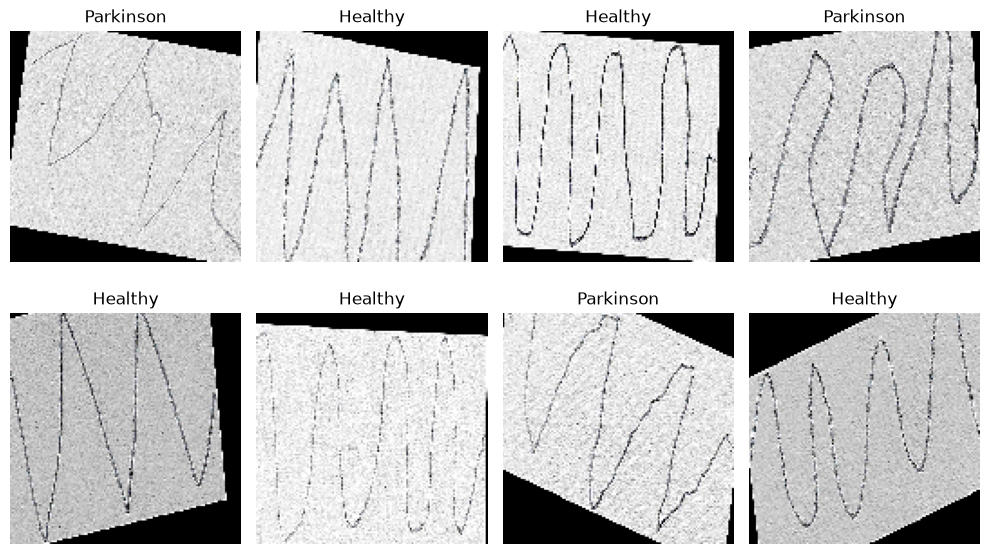

In [102]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(10, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    plt.title("Parkinson" if labels[i] == 1 else "Healthy")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [103]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

wave_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    GlobalAveragePooling2D(),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

wave_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

wave_model.summary()

c:\Users\Sharmila S\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,617 (92.25 KB)

 Trainable params: 23,617 (92.25 KB)

 Non-trainable params: 0 (0.00 B)

In [104]:
wave_history = wave_model.fit(
    wave_train_generator,
    validation_data=wave_validation_generator,
    epochs=15
)

Epoch 1/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - accuracy: 0.4826 - loss: 0.7105 - val_accuracy: 0.5000 - val_loss: 0.6967
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - accuracy: 0.4861 - loss: 0.6973 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step - accuracy: 0.4583 - loss: 0.6993 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.5417 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.5035 - loss: 0.6922 - val_accuracy: 0.5000 - val_loss: 0.6924
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step - accuracy: 0.4514 - loss: 0.7003 - val_accuracy: 0.5000 - val_loss: 0.6920
Epoch 7/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 194ms/step - accuracy: 0.5278 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6920
Epoch 8/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step - accuracy: 0.4896 - loss: 0.6942 - val_accuracy: 0.

In [105]:
wave_test_generator.reset()

wave_test_loss, wave_test_accuracy = wave_model.evaluate(
    wave_test_generator
)

print("Wave Test Loss:", wave_test_loss)
print("Wave Test Accuracy:", wave_test_accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.5000 - loss: 0.6922
Wave Test Loss: 0.6922074556350708
Wave Test Accuracy: 0.5


In [106]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

wave_test_generator.reset()

predictions = wave_model.predict(wave_test_generator)

y_pred = (predictions > 0.5).astype(int).flatten()
y_true = wave_test_generator.classes

print("Wave Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Healthy", "Parkinson"]
))

print("Wave Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step
Wave Classification Report:
              precision    recall  f1-score   support

     Healthy       0.50      0.99      0.66        75
   Parkinson       0.50      0.01      0.03        75

    accuracy                           0.50       150
   macro avg       0.50      0.50      0.34       150
weighted avg       0.50      0.50      0.34       150

Wave Confusion Matrix:
[[74  1]
 [74  1]]


In [107]:
import joblib
import numpy as np
import pandas as pd
from PIL import Image
import os

# Prefer the enhanced class-balanced voice model.
if os.path.exists("parkinsons_model_balanced.pkl"):
    voice_model = joblib.load("parkinsons_model_balanced.pkl")
    print("Loaded enhanced balanced voice model.")
else:
    voice_model = joblib.load("parkinsons_model.pkl")
    print("Loaded legacy voice model. Run the enhanced voice notebook first for the balanced model.")

VOICE_FEATURE_NAMES = [
    "MDVP:Fo(Hz)", "MDVP:Fhi(Hz)", "MDVP:Flo(Hz)", "MDVP:Jitter(%)",
    "MDVP:Jitter(Abs)", "MDVP:RAP", "MDVP:PPQ", "Jitter:DDP",
    "MDVP:Shimmer", "MDVP:Shimmer(dB)", "Shimmer:APQ3", "Shimmer:APQ5",
    "MDVP:APQ", "Shimmer:DDA", "NHR", "HNR", "RPDE", "DFA",
    "spread1", "spread2", "D2", "PPE"
]

Loaded legacy voice model. Run the enhanced voice notebook first for the balanced model.


In [108]:
def get_voice_probability(voice_features):
    """
    voice_features: list/array of 22 values in VOICE_FEATURE_NAMES order,
    or a dict {feature_name: value}.
    Returns probability of Parkinson's (class 1) from the voice RF model.
    """
    if isinstance(voice_features, dict):
        voice_features = [voice_features[f] for f in VOICE_FEATURE_NAMES]

    voice_df = pd.DataFrame([voice_features], columns=VOICE_FEATURE_NAMES)
    prob = voice_model.predict_proba(voice_df)[0][1]
    return float(prob)


def get_spiral_probability(image_path):
    """
    image_path: path to a spiral drawing image.
    Uses the fine-tuned MobileNetV2 model ('model') trained earlier on spiral images.
    """
    img = Image.open(image_path).convert("RGB").resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prob = model.predict(img_array, verbose=0)[0][0]
    return float(prob)


def get_wave_probability(image_path):
    """
    image_path: path to a wave drawing image.
    Uses 'wave_model' (CNN trained from scratch earlier on wave images).
    """
    img = Image.open(image_path).convert("RGB").resize((128, 128))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prob = wave_model.predict(img_array, verbose=0)[0][0]
    return float(prob)

In [109]:
def predict_parkinsons_multimodal(
    voice_features,
    spiral_image_path,
    wave_image_path,
    weights=(0.50, 0.30, 0.20),   # (voice, spiral, wave) - same weighting as combine_predictions() above
    threshold=0.5
):
    """
    Runs all three trained models on a single patient's data and combines
    them into one weighted-average prediction.
    """
    voice_prob = get_voice_probability(voice_features)
    spiral_prob = get_spiral_probability(spiral_image_path)
    wave_prob = get_wave_probability(wave_image_path)

    w_voice, w_spiral, w_wave = weights
    combined_score = (
        w_voice * voice_prob +
        w_spiral * spiral_prob +
        w_wave * wave_prob
    )

    result = "Parkinson's" if combined_score >= threshold else "Healthy"

    return {
        "voice_probability": round(voice_prob, 4),
        "spiral_probability": round(spiral_prob, 4),
        "wave_probability": round(wave_prob, 4),
        "combined_score": round(combined_score, 4),
        "prediction": result
    }

In [110]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# -----------------------------------
# YOUR EXISTING PREDICTION
# -----------------------------------

sample_voice_features = [
    119.992, 157.302, 74.997, 0.00784, 0.00007, 0.00370, 0.00554,
    0.01109, 0.04374, 0.426, 0.02182, 0.03130, 0.02971, 0.06545,
    21.033, 19.085, 0.414783, 0.815285, 0.778834, 2.301442,
    0.266482, 0.284654
]

sample_spiral_image = os.path.join(
    "./spiral/testing/parkinson",
    os.listdir("./spiral/testing/parkinson")[0]
)

sample_wave_image = os.path.join(
    "./wave/testing/parkinson",
    os.listdir("./wave/testing/parkinson")[0]
)

result = predict_parkinsons_multimodal(
    voice_features=sample_voice_features,
    spiral_image_path=sample_spiral_image,
    wave_image_path=sample_wave_image
)

print(result)

{'voice_probability': 0.9967, 'spiral_probability': 0.5656, 'wave_probability': 0.4736, 'combined_score': 0.7628, 'prediction': "Parkinson's"}


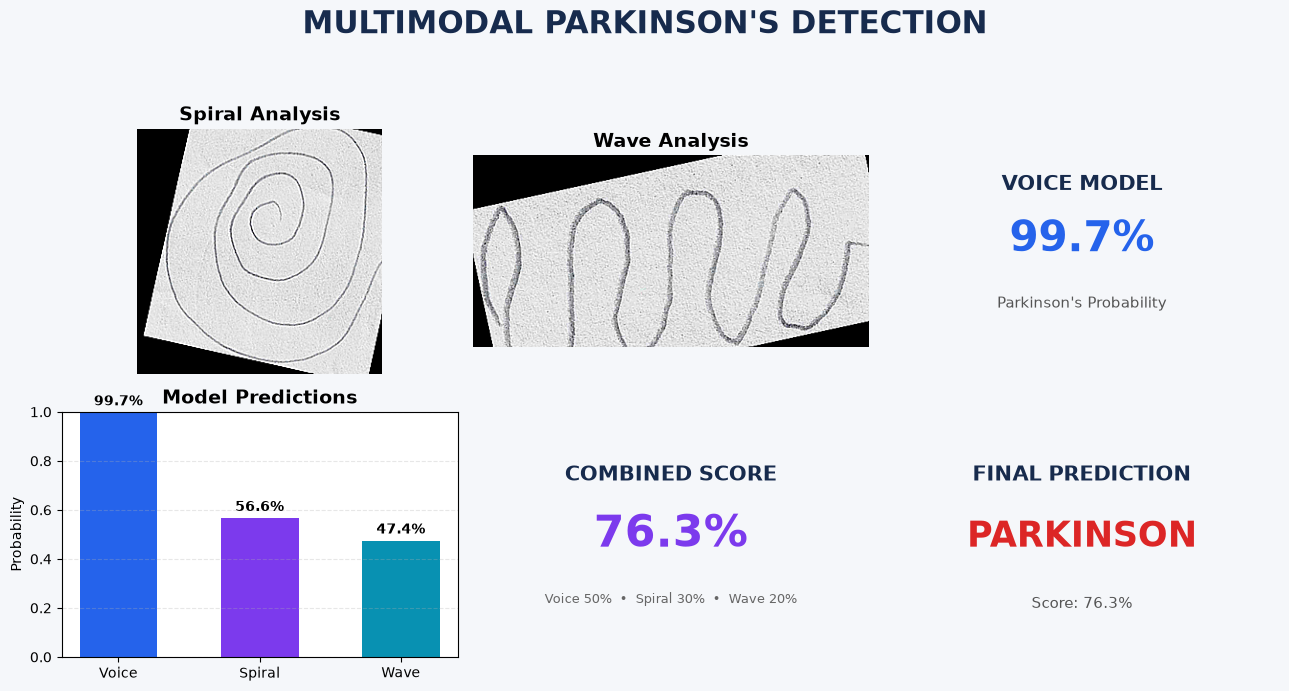

In [111]:
# ==========================================
# MULTIMODAL PARKINSON'S RESULT
# ==========================================

# If your function returns the probabilities
# as a dictionary, get them like this.

voice_prob = result["voice_probability"]
spiral_prob = result["spiral_probability"]
wave_prob = result["wave_probability"]

# Calculate combined score
combined_score = (
    0.50 * voice_prob +
    0.30 * spiral_prob +
    0.20 * wave_prob
)

# Final prediction
if combined_score >= 0.5:
    prediction = "PARKINSON"
    prediction_color = "#DC2626"
else:
    prediction = "HEALTHY"
    prediction_color = "#16A34A"


# ==========================================
# CREATE FIGURE
# ==========================================

fig = plt.figure(figsize=(13, 7))
fig.patch.set_facecolor("#F5F7FA")

fig.suptitle(
    "MULTIMODAL PARKINSON'S DETECTION",
    fontsize=22,
    fontweight="bold",
    color="#172B4D"
)


# ==========================================
# SPIRAL IMAGE
# ==========================================

ax1 = plt.subplot(2, 3, 1)

spiral_img = Image.open(sample_spiral_image)

ax1.imshow(spiral_img)
ax1.set_title(
    "Spiral Analysis",
    fontsize=14,
    fontweight="bold"
)

ax1.axis("off")


# ==========================================
# WAVE IMAGE
# ==========================================

ax2 = plt.subplot(2, 3, 2)

wave_img = Image.open(sample_wave_image)

ax2.imshow(wave_img)
ax2.set_title(
    "Wave Analysis",
    fontsize=14,
    fontweight="bold"
)

ax2.axis("off")


# ==========================================
# VOICE RESULT
# ==========================================

ax3 = plt.subplot(2, 3, 3)

ax3.axis("off")

ax3.text(
    0.5, 0.75,
    "VOICE MODEL",
    ha="center",
    fontsize=15,
    fontweight="bold",
    color="#172B4D"
)

ax3.text(
    0.5, 0.50,
    f"{voice_prob * 100:.1f}%",
    ha="center",
    fontsize=30,
    fontweight="bold",
    color="#2563EB"
)

ax3.text(
    0.5, 0.27,
    "Parkinson's Probability",
    ha="center",
    fontsize=11,
    color="#555555"
)


# ==========================================
# MODEL COMPARISON
# ==========================================

ax4 = plt.subplot(2, 3, 4)

models = ["Voice", "Spiral", "Wave"]

probabilities = [
    voice_prob,
    spiral_prob,
    wave_prob
]

colors = [
    "#2563EB",
    "#7C3AED",
    "#0891B2"
]

bars = ax4.bar(
    models,
    probabilities,
    color=colors,
    width=0.55
)

ax4.set_ylim(0, 1)

ax4.set_ylabel(
    "Probability",
    fontsize=10
)

ax4.set_title(
    "Model Predictions",
    fontsize=14,
    fontweight="bold"
)

ax4.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar, value in zip(bars, probabilities):

    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.03,
        f"{value * 100:.1f}%",
        ha="center",
        fontweight="bold"
    )


# ==========================================
# COMBINED SCORE
# ==========================================

ax5 = plt.subplot(2, 3, 5)

ax5.axis("off")

ax5.text(
    0.5, 0.72,
    "COMBINED SCORE",
    ha="center",
    fontsize=15,
    fontweight="bold",
    color="#172B4D"
)

ax5.text(
    0.5, 0.45,
    f"{combined_score * 100:.1f}%",
    ha="center",
    fontsize=32,
    fontweight="bold",
    color="#7C3AED"
)

ax5.text(
    0.5, 0.22,
    "Voice 50%  •  Spiral 30%  •  Wave 20%",
    ha="center",
    fontsize=9,
    color="#666666"
)


# ==========================================
# FINAL PREDICTION
# ==========================================

ax6 = plt.subplot(2, 3, 6)

ax6.axis("off")

ax6.text(
    0.5, 0.72,
    "FINAL PREDICTION",
    ha="center",
    fontsize=15,
    fontweight="bold",
    color="#172B4D"
)

ax6.text(
    0.5, 0.45,
    prediction,
    ha="center",
    fontsize=25,
    fontweight="bold",
    color=prediction_color
)

ax6.text(
    0.5, 0.20,
    f"Score: {combined_score * 100:.1f}%",
    ha="center",
    fontsize=11,
    color="#555555"
)


# ==========================================
# DISPLAY
# ==========================================

plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()


In [112]:
from sklearn.metrics import accuracy_score

# Recompute each classical model's test accuracy from the model object itself
rf_ink_acc          = accuracy          # ink-ratio features RF (cell 21) - never overwritten, safe as-is
rf_hog_acc           = accuracy_score(y_test, rf_hog.predict(X_test))          # HOG features, same X_test/y_test used by svm/dt/lr/knn below
svm_hog_acc          = test_accuracy_svm
dt_hog_acc           = test_accuracy_dt
lr_hog_acc           = test_accuracy_lr
knn_hog_acc          = test_accuracy_knn
rf_pca_acc           = test_accuracy_pca
rf_wave_acc          = accuracy_score(y_wave_test, rf_wave.predict(X_wave_test))
rf_combined_acc      = combined_test_accuracy
spiral_cnn_acc       = test_accuracy        # cell 65 (MobileNetV2, overwrote rf_hog's value of same name — this is the correct final one)
wave_cnn_acc         = wave_test_accuracy   # cell 77 (CNN from scratch, overwrote rf_wave's value of same name — this is the correct final one)

results_df = pd.DataFrame({
    "Model": [
        "RF (ink features)", "RF (HOG)", "SVM (HOG)", "Decision Tree (HOG)",
        "Logistic Regression (HOG)", "KNN (HOG)", "RF (HOG + PCA)",
        "RF (Wave, HOG)", "RF (Spiral+Wave combined)",
        "CNN - MobileNetV2 (Spiral)", "CNN from scratch (Wave)"
    ],
    "Test Accuracy": [
        rf_ink_acc, rf_hog_acc, svm_hog_acc, dt_hog_acc, lr_hog_acc,
        knn_hog_acc, rf_pca_acc, rf_wave_acc, rf_combined_acc,
        spiral_cnn_acc, wave_cnn_acc
    ]
}).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

results_df

,Model,Test Accuracy
0,CNN - MobileNetV2 (Spiral),0.753333
1,RF (Spiral+Wave combined),0.690909
2,RF (HOG),0.666667
3,Logistic Regression (HOG),0.633333
4,SVM (HOG),0.626667
5,"RF (Wave, HOG)",0.626667
6,RF (ink features),0.613333
7,KNN (HOG),0.613333
8,RF (HOG + PCA),0.580000
9,Decision Tree (HOG),0.546667


In [113]:
from sklearn.metrics import roc_curve, auc

def get_proba(clf, X):
    """Return a Parkinson's-probability-like score for ROC, regardless of classifier type."""
    if hasattr(clf, "predict_proba"):
        return clf.predict_proba(X)[:, 1]
    return clf.decision_function(X)


def plot_roc_curves(model_predictions, title="ROC Curve Comparison"):
    """
    model_predictions: dict of {model_name: (y_true, y_score)}
    """
    plt.figure(figsize=(8, 6))
    for name, (y_true, y_score) in model_predictions.items():
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

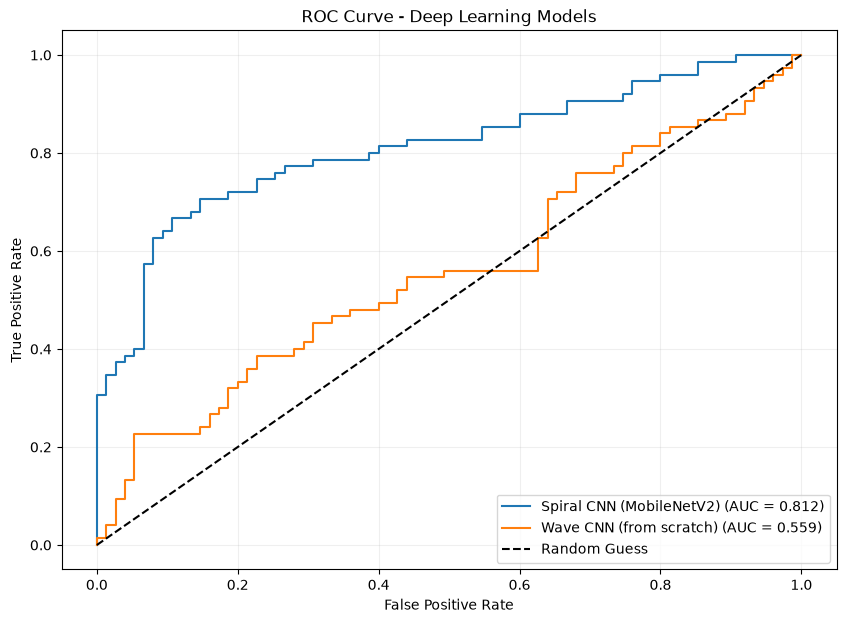

ROC-AUC RESULTS
Spiral CNN AUC : 0.812
Wave CNN AUC   : 0.559

Note: Each model was evaluated on its own test dataset.


In [114]:
# ============================================================
# ROC CURVE - DEEP LEARNING MODELS
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score


# ------------------------------------------------------------
# 1. SPIRAL CNN
# ------------------------------------------------------------

test_generator.reset()

spiral_cnn_probs = model.predict(
    test_generator,
    verbose=0
).flatten()

spiral_cnn_true = test_generator.classes


# ------------------------------------------------------------
# 2. WAVE CNN
# ------------------------------------------------------------

wave_test_generator.reset()

wave_cnn_probs = wave_model.predict(
    wave_test_generator,
    verbose=0
).flatten()

wave_cnn_true = wave_test_generator.classes


# ------------------------------------------------------------
# 3. CALCULATE ROC CURVES
# ------------------------------------------------------------

spiral_fpr, spiral_tpr, _ = roc_curve(
    spiral_cnn_true,
    spiral_cnn_probs
)

wave_fpr, wave_tpr, _ = roc_curve(
    wave_cnn_true,
    wave_cnn_probs
)


# ------------------------------------------------------------
# 4. CALCULATE AUC
# ------------------------------------------------------------

spiral_auc = roc_auc_score(
    spiral_cnn_true,
    spiral_cnn_probs
)

wave_auc = roc_auc_score(
    wave_cnn_true,
    wave_cnn_probs
)


# ------------------------------------------------------------
# 5. PLOT ROC CURVES
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.plot(
    spiral_fpr,
    spiral_tpr,
    label=f"Spiral CNN (MobileNetV2) (AUC = {spiral_auc:.3f})"
)

plt.plot(
    wave_fpr,
    wave_tpr,
    label=f"Wave CNN (from scratch) (AUC = {wave_auc:.3f})"
)

# Random guessing line
plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Guess"
)


plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Deep Learning Models"
)

plt.legend(
    loc="lower right"
)

plt.grid(alpha=0.2)

plt.show()


# ------------------------------------------------------------
# 6. PRINT RESULTS
# ------------------------------------------------------------

print("==========================================")
print("ROC-AUC RESULTS")
print("==========================================")

print(
    f"Spiral CNN AUC : {spiral_auc:.3f}"
)

print(
    f"Wave CNN AUC   : {wave_auc:.3f}"
)

print()
print(
    "Note: Each model was evaluated on its own test dataset."
)

HANDWRITING MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Spiral CNN,0.7533,0.7714,0.7200,0.7448,0.8119
1,Wave CNN,0.5000,0.5000,0.0133,0.0260,0.5588


<Figure size 500x400 with 0 Axes>

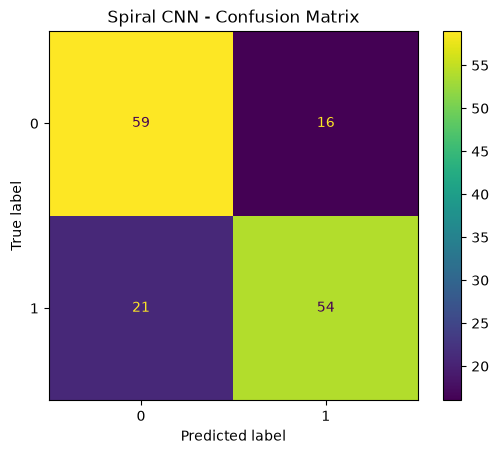

<Figure size 500x400 with 0 Axes>

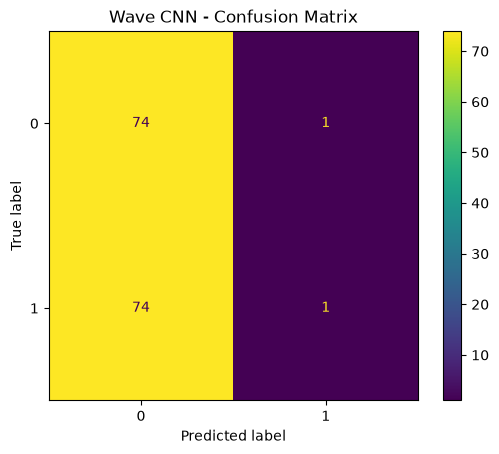


BEST HANDWRITING MODEL
Spiral CNN has the highest F1 Score: 0.7448

Results saved as:
handwriting_model_comparison.csv


In [115]:
# ============================================================
# SIMPLE HANDWRITING MODEL EVALUATION
# Spiral CNN + Wave CNN
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. SPIRAL MODEL PREDICTIONS
# ============================================================

test_generator.reset()

spiral_prob = model.predict(
    test_generator,
    verbose=0
).flatten()

spiral_y = test_generator.classes

spiral_pred = (
    spiral_prob >= 0.5
).astype(int)


# ============================================================
# 2. WAVE MODEL PREDICTIONS
# ============================================================

wave_test_generator.reset()

wave_prob = wave_model.predict(
    wave_test_generator,
    verbose=0
).flatten()

wave_y = wave_test_generator.classes

wave_pred = (
    wave_prob >= 0.5
).astype(int)


# ============================================================
# 3. FUNCTION TO CALCULATE METRICS
# ============================================================

def calculate_metrics(y_true, probability, prediction, model_name):

    return {
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_true,
            prediction
        ),

        "Precision": precision_score(
            y_true,
            prediction,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            prediction,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_true,
            prediction,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            probability
        )
    }


# ============================================================
# 4. COMPARE SPIRAL AND WAVE MODELS
# ============================================================

results = [

    calculate_metrics(
        spiral_y,
        spiral_prob,
        spiral_pred,
        "Spiral CNN"
    ),

    calculate_metrics(
        wave_y,
        wave_prob,
        wave_pred,
        "Wave CNN"
    )
]


results_df = pd.DataFrame(results)


print("==========================================")
print("HANDWRITING MODEL COMPARISON")
print("==========================================")

display(
    results_df.round(4)
)


# ============================================================
# 5. CONFUSION MATRIX — SPIRAL
# ============================================================

plt.figure(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    spiral_y,
    spiral_pred
)

plt.title("Spiral CNN - Confusion Matrix")

plt.show()


# ============================================================
# 6. CONFUSION MATRIX — WAVE
# ============================================================

plt.figure(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    wave_y,
    wave_pred
)

plt.title("Wave CNN - Confusion Matrix")

plt.show()


# ============================================================
# 7. FIND THE BETTER MODEL
# ============================================================

best_model = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

best_f1 = results_df["F1 Score"].max()

print()
print("==========================================")
print("BEST HANDWRITING MODEL")
print("==========================================")

print(
    f"{best_model} has the highest F1 Score: "
    f"{best_f1:.4f}"
)


# ============================================================
# 8. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "handwriting_model_comparison.csv",
    index=False
)

print()
print("Results saved as:")
print("handwriting_model_comparison.csv")
